# Similarité entre classements (Rank-Based Overlap)

Ce notebook compare les classements produits par les quatre méthodes de l'ATS
sur le run `all_rankings_20260618-174237` :

- `baseline_keyword_match` — mots-clés (regex + stopwords FR/EN)
- `ml6_keyword_match` — mots-clés (modèle ml6team)
- `embedding_cosine` — similarité cosinus (all-MiniLM-L6-v2)
- `sliding_window_ranking` — classement LLM par fenêtre glissante (Claude) — **référence**

La similarité entre deux classements est mesurée par le **Rank-Based Overlap (RBO)**
(Webber et al., 2010), une métrique bornée dans `[0, 1]` qui pondère davantage le
haut du classement (les meilleurs candidats), ce qui est pertinent pour un ATS où
seuls les premiers CVs sont réellement examinés. Le classement par **fenêtre
glissante (Claude)** sert de référence : on calcule le RBO de chaque autre méthode
vis-à-vis de lui.

In [1]:
import json

import matplotlib.pyplot as plt

from ats_system.config import RESULTS_DIR

RUN_DIR = RESULTS_DIR / "all_rankings_20260618-174237"
REFERENCE_METHOD = "sliding_window_ranking"  # classement de référence
RBO_P = 0.9  # persistance : ~86 % du poids sur les 10 premiers rangs
RUN_DIR

WindowsPath('C:/Users/Antoine/Documents/prog/python/ats-system/results/all_rankings_20260618-174237')

In [2]:
def load_ranking(path):
    """Lit un JSON de résultats et retourne (method, [cv_id, ...] ordonné)."""
    payload = json.loads(path.read_text(encoding="utf-8"))
    ordered = [entry["cv_id"] for entry in payload["ranking"]]
    return payload["method"], ordered


# Un seul fichier par méthode dans le dossier de run.
rankings = {}
for path in sorted(RUN_DIR.glob("*.json")):
    method, ordered = load_ranking(path)
    rankings[method] = ordered
    print(f"{method:<26} : {len(ordered)} CVs")

assert REFERENCE_METHOD in rankings, f"Référence {REFERENCE_METHOD!r} introuvable dans {RUN_DIR}"

baseline_keyword_match     : 30 CVs
embedding_cosine           : 30 CVs
ml6_keyword_match          : 30 CVs
sliding_window_ranking     : 30 CVs


In [3]:
def rbo(list_a, list_b, p=0.9):
    """Rank-Based Overlap (variante extrapolée RBO_ext) entre deux classements.

    Mesure la similarité de deux listes ordonnées en pondérant le haut du
    classement (poids décroissant en p^d). Retourne une valeur dans [0, 1] :
    1.0 = listes identiques, 0.0 = aucun chevauchement.

    Args:
        list_a, list_b: classements (listes d'identifiants, du meilleur au pire).
        p:              persistance dans ]0, 1[ ; plus p est proche de 1, plus le
                        poids s'étale en profondeur.
    """
    if not list_a or not list_b:
        return 0.0

    k = min(len(list_a), len(list_b))
    seen_a, seen_b = set(), set()
    overlap = 0  # |top-d(A) ∩ top-d(B)|
    sum_weighted = 0.0  # Σ_{d=1}^{k} (X_d / d) · p^d

    for d in range(1, k + 1):
        a, b = list_a[d - 1], list_b[d - 1]
        seen_a.add(a)
        seen_b.add(b)
        if a == b:
            overlap += 1
        else:
            if a in seen_b:
                overlap += 1
            if b in seen_a:
                overlap += 1
        sum_weighted += (overlap / d) * (p ** d)

    # Terme extrapolé : suppose que le chevauchement au-delà de k se poursuit au
    # taux observé X_k / k.
    x_k = overlap / k
    return (1 - p) / p * sum_weighted + x_k * (p ** k)

In [4]:
reference = rankings[REFERENCE_METHOD]

# RBO de chaque méthode face à la référence (la référence est exclue d'elle-même).
scores = {
    method: rbo(reference, ordered, p=RBO_P)
    for method, ordered in rankings.items()
    if method != REFERENCE_METHOD
}
scores = dict(sorted(scores.items(), key=lambda kv: kv[1], reverse=True))

for method, value in scores.items():
    print(f"{method:<26} RBO = {value:.3f}")

ml6_keyword_match          RBO = 0.705
embedding_cosine           RBO = 0.608
baseline_keyword_match     RBO = 0.320


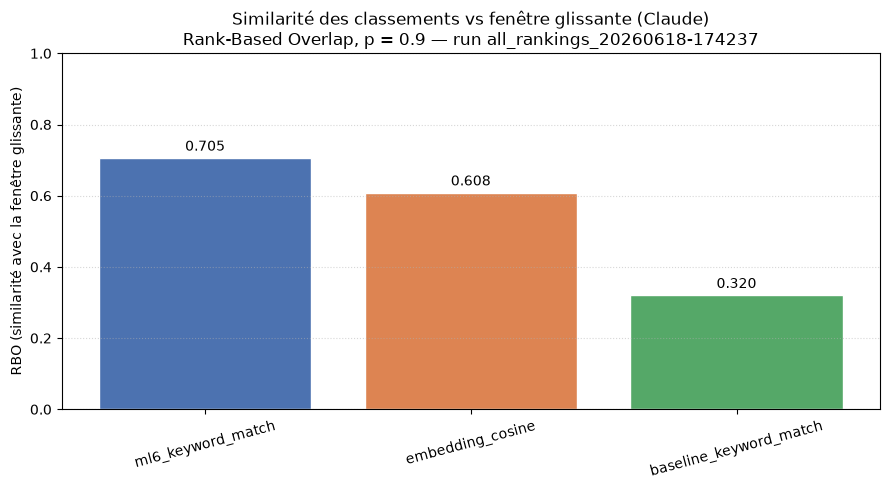

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

methods = list(scores.keys())
values = list(scores.values())
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"][: len(methods)]

bars = ax.bar(methods, values, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3)

ax.set_ylim(0, 1)
ax.set_ylabel("RBO (similarité avec la fenêtre glissante)")
ax.set_title(
    f"Similarité des classements vs fenêtre glissante (Claude)\n"
    f"Rank-Based Overlap, p = {RBO_P} — run all_rankings_20260618-174237"
)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()